Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 8, in <module>
    sys.exit(main())
  File "/usr/local/lib/python3.10/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
KeyError: 'username'
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total Images: 14034
Found existing installation: transformers 5.10.1
Uninstalling transformers-5.10.1:
  Successfully uninstalled transformers-5.10.1
Found exi

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pytorch-triton             3.0.0+dedb7bdf3
torch                      2.4.1
torch_tensorrt             2.5.0a0
torchprofile               0.0.4
torchvision                0.19.1
transformers               4.48.3
Found existing installation: flash_attn 2.4.2
Uninstalling flash_attn-2.4.2:
  Successfully uninstalled flash_attn-2.4.2


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Predicted Class: solar dish, solar collector, solar furnace


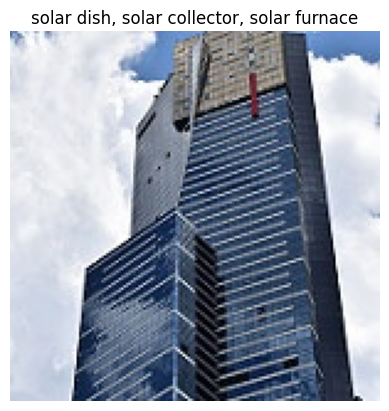

10004.jpg -> palace
10005.jpg -> valley, vale
10012.jpg -> jinrikisha, ricksha, rickshaw
10013.jpg -> valley, vale
10017.jpg -> cliff, drop, drop-off
10021.jpg -> valley, vale
1003.jpg -> sandbar, sand bar
10034.jpg -> dough
10038.jpg -> drilling platform, offshore rig
10040.jpg -> traffic light, traffic signal, stoplight


In [8]:
# Install Libraries
!pip install transformers datasets torch torchvision pillow matplotlib

# Download Dataset
!kaggle datasets download -d puneet6060/intel-image-classification
import zipfile
with zipfile.ZipFile("intel-image-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("intel_dataset")
from torchvision import datasets
train_dir = "intel_dataset/seg_train/seg_train"
dataset = datasets.ImageFolder(train_dir)
print("Classes:", dataset.classes)
print("Total Images:", len(dataset))
!pip uninstall -y transformers torch torchvision
!pip install torch==2.4.1 torchvision==0.19.1
!pip install transformers==4.48.3
import torch
import transformers
print("Torch Version:", torch.__version__)
print("Transformers Version:", transformers.__version__)
!pip list | grep torch
!pip list | grep transformers
!pip uninstall -y flash-attn flash_attn
from transformers import AutoImageProcessor
from transformers import AutoModelForImageClassification
model_name = "google/mobilenet_v2_1.0_224"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)
from PIL import Image
import torch
image_path = "intel_dataset/seg_test/seg_test/buildings/20057.jpg"
image = Image.open(image_path)
inputs = processor(images=image,
                   return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
predicted_class = outputs.logits.argmax(-1).item()
print("Predicted Class:",
      model.config.id2label[predicted_class])
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.title(model.config.id2label[predicted_class])
plt.show()
import os
test_folder = "intel_dataset/seg_pred/seg_pred"
files = os.listdir(test_folder)[:10]
for file in files:
    img = Image.open(os.path.join(test_folder, file))
    inputs = processor(images=img,
                       return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    pred = outputs.logits.argmax(-1).item()
    print(file, "->",
          model.config.id2label[pred])


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 8, in <module>
    sys.exit(main())
  File "/usr/local/lib/python3.10/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
KeyError: 'username'
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total Images: 14034
Found existing installation: transformers 4.48.3
Uninstalling transformers-4.48.3:
  Successfully uninstalled transformers-4.48.3
Found exi

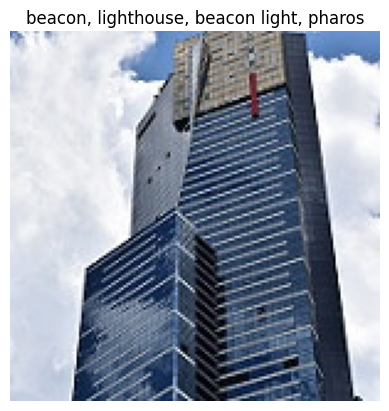

10004.jpg -> palace
10005.jpg -> mountain tent
10012.jpg -> streetcar, tram, tramcar, trolley, trolley car
10013.jpg -> barn
10017.jpg -> alp
10021.jpg -> valley, vale
1003.jpg -> sandbar, sand bar
10034.jpg -> cliff, drop, drop-off
10038.jpg -> drilling platform, offshore rig
10040.jpg -> traffic light, traffic signal, stoplight


In [9]:
# Install Libraries
!pip install transformers datasets torch torchvision pillow matplotlib

# Download Dataset
!kaggle datasets download -d puneet6060/intel-image-classification
import zipfile
with zipfile.ZipFile("intel-image-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("intel_dataset")
from torchvision import datasets
train_dir = "intel_dataset/seg_train/seg_train"
dataset = datasets.ImageFolder(train_dir)
print("Classes:", dataset.classes)
print("Total Images:", len(dataset))
!pip uninstall -y transformers torch torchvision
!pip install torch==2.4.1 torchvision==0.19.1
!pip install transformers==4.48.3
import torch
import transformers
print("Torch Version:", torch.__version__)
print("Transformers Version:", transformers.__version__)
!pip list | grep torch
!pip list | grep transformers
!pip uninstall -y flash-attn flash_attn
from transformers import AutoImageProcessor
from transformers import AutoModelForImageClassification
model_name = "microsoft/resnet-50"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)
from PIL import Image
import torch
image_path = "intel_dataset/seg_test/seg_test/buildings/20057.jpg"
image = Image.open(image_path)
inputs = processor(images=image,
                   return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
predicted_class = outputs.logits.argmax(-1).item()
print("Predicted Class:",
      model.config.id2label[predicted_class])
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.title(model.config.id2label[predicted_class])
plt.show()
import os
test_folder = "intel_dataset/seg_pred/seg_pred"
files = os.listdir(test_folder)[:10]
for file in files:
    img = Image.open(os.path.join(test_folder, file))
    inputs = processor(images=img,
                       return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    pred = outputs.logits.argmax(-1).item()
    print(file, "->",
          model.config.id2label[pred])
